In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.stats.api as sm

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean_V2.csv")

/tmp/ipykernel_20607/3431967841.py:8: DtypeWarning: Columns (35,36,98,99,101,102,105,107,111) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean_V2.csv")


# Results of pncA Clustering on Summed Positive Saliency Scores

In [2]:
out_dir = "PZA_CNN"
pncA_positive_saliency = pd.read_csv(f"{out_dir}/pncA_mutations_positive_saliency.csv")

pncA_structure_coords = np.load("I6XD65.npy")
pncA_distance_map = pd.read_csv("I6XD65.csv")

pncA_structure_coords.shape, len(pncA_distance_map), len(pncA_positive_saliency)

((185, 185), 185, 159)

In [3]:
GeO_scores = pd.read_csv(f"{out_dir}/G_scores.csv").merge(pncA_positive_saliency, on='residue')

# these are GeO scores for each residue after shuffling the residues
# permutation test to see if the GeO score for each residue is significantly different from the the null
GeO_permutation_results = pd.read_csv(f"{out_dir}/random_GeO_iterations_10000.csv.gz", compression="gzip", index_col=[0])

# GeO_pvalues = pd.read_csv(f"{out_dir}/random_GeO_pvalues_10000.csv.gz", compression="gzip")

In [4]:
for i, row in GeO_scores.iterrows():

    residue = row['residue']
    GeO_score = row['G_score']

    # what proportion of the permuted Getis-Ord statistics are at least as extreme as the Getis-Ord statistic for a given residue
    if GeO_score > 0:
        pvalue = np.mean(GeO_permutation_results.loc[residue, :].values >= GeO_score)
    else:
        pvalue = np.mean(GeO_permutation_results.loc[residue, :].values <= GeO_score)

    GeO_scores.loc[i, "pval"] = pvalue

_, bh_pvals, _, _ = sm.multipletests(GeO_scores["pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
_, bonferroni_pvals, _, _ = sm.multipletests(GeO_scores["pval"], method='bonferroni', is_sorted=False, returnsorted=False)

GeO_scores['BH_pval'] = bh_pvals
GeO_scores['Bonferroni_pval'] = bonferroni_pvals

pval_thresh = 0.1
GeO_scores["significant"] = (GeO_scores['BH_pval'] < pval_thresh).astype(int)

In [5]:
# catalytic triad: 8, 96, and 138, which form the active site. I think computational ligand docking experiments also show this region?
residues_lst = GeO_scores.query("BH_pval < @pval_thresh").residue.values.astype(str)
GeO_scores.query("BH_pval < @pval_thresh")

,residue,G_score,summed,pval,BH_pval,Bonferroni_pval,significant
4,5,41.582433,0.794217,0.0069,0.073140,1.0000,1
6,7,54.913469,0.030422,0.0011,0.035333,0.1749,1
76,96,41.794175,1.246852,0.0067,0.073140,1.0000,1
109,130,61.707039,1.494644,0.0005,0.035333,0.0795,1
110,131,52.065749,2.360108,0.0018,0.035333,0.2862,1
111,132,47.296966,2.221799,0.0052,0.063600,0.8268,1
114,135,72.828730,0.262849,0.0001,0.015900,0.0159,1
116,137,50.951173,0.404338,0.0023,0.036570,0.3657,1
118,139,52.470393,0.521914,0.0015,0.035333,0.2385,1
138,161,46.204106,0.831918,0.0047,0.062275,0.7473,1


In [6]:
len(GeO_scores.query("BH_pval < @pval_thresh"))

15

In [41]:
#GeO_scores.query("residue in @num_missing")

In [7]:
GeO_scores.query("residue in [8, 13, 68, 96, 138]")

,residue,G_score,summed,pval,BH_pval,Bonferroni_pval,significant
7,8,8.033230,2.814490,0.2533,0.387960,1.0,0
51,68,1.446289,0.000830,0.4087,0.464734,1.0,0
76,96,41.794175,1.246852,0.0067,0.073140,1.0,1
117,138,34.309632,0.374428,0.0205,0.131016,1.0,0


In [164]:
who_variants.query("gene=='pncA' & mutation.str.contains('|'.join(@residues_lst))").confidence.value_counts()

confidence
2) Assoc w R - Interim        47
3) Uncertain significance     47
1) Assoc w R                  32
4) Not assoc w R - Interim     9
Name: count, dtype: int64

In [180]:
who_variants.query("gene=='pncA' & mutation.str.contains('|'.join(['130', '131', '132', '135', '137', '139']))").confidence.value_counts()

confidence
2) Assoc w R - Interim        11
1) Assoc w R                   9
3) Uncertain significance      7
4) Not assoc w R - Interim     2
Name: count, dtype: int64

In [181]:
who_variants.query("gene=='pncA' & mutation.str.contains('|'.join(['170', '171', '172', '173', '174']))").confidence.value_counts()

confidence
3) Uncertain significance    8
2) Assoc w R - Interim       5
1) Assoc w R                 2
Name: count, dtype: int64

In [ ]:
Across the 11 residues with significant Getis-Ord clustering of positive saliency scores, there are   

<Axes: xlabel='residue', ylabel='G_score'>

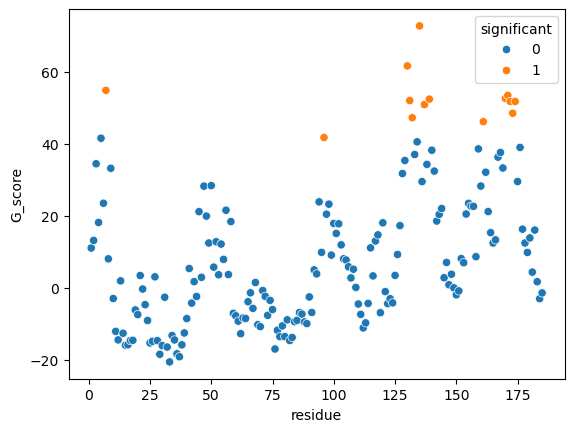

In [43]:
sns.scatterplot(data=GeO_scores,
                x='residue',
                y='G_score',
                hue='significant'
               )

<Axes: xlabel='residue', ylabel='summed'>

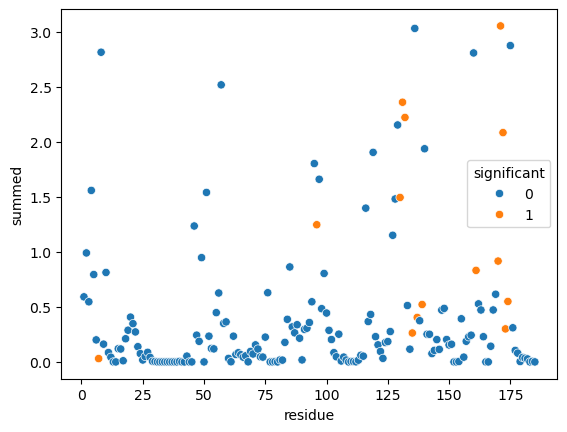

In [44]:
# interesting, some of the residue with significant positive Getis-Ord statistics have low saliency scores actually
sns.scatterplot(data=GeO_scores,
                x='residue',
                y='summed',
                hue='significant'
               )

# Curious about correlations between saliency scores and Getis-Ord statistics

In [216]:
st.spearmanr(GeO_scores['summed'], GeO_scores['G_score'])

SignificanceResult(statistic=0.5190171960831144, pvalue=2.4034654333644e-12)

In [217]:
st.pearsonr(GeO_scores['summed'], GeO_scores['G_score'])

PearsonRResult(statistic=0.42052137553948493, pvalue=3.413442580589201e-08)